<a href="https://colab.research.google.com/github/leejungp2/dl-study/blob/main/260531_04_pytorch_custom_datasets_exercise_%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercise

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [ ]:
# Check for GPU
!nvidia-smi

Sun Jun  7 10:43:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.11.0+cu128


'cuda'

## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

> 모델이 성능이 좋지 않습니다(데이터에 잘 맞지 않습니다). 언더피팅을 방지하는 3가지 방법은 무엇인가요? 각각을 적고 한 문장으로 설명하세요.

언더피팅을 방지하는 핵심 아이디어는 다음과 같음.

> 모델의 예측 능력을 높이는 것

1. **모델에 더 많은 레이어/유닛을 추가함(모델 복잡도 증가).**  
   모델 복잡도를 높이면 훈련 데이터 안의 일반화 가능한 패턴을 학습할 기회가 더 많아질 수 있음.  
   예를 들어, 은닉층을 2개 사용하는 대신 4개로 늘릴 수 있음.

2. **전이 학습을 사용함.**  
   전이 학습은 이미 다른 모델이나 데이터셋에서 학습된 유용한 패턴을 가져와 자신의 문제에 활용함으로써 언더피팅을 방지하는 데 도움을 줌.

3. **모델을 더 오래 훈련함.**  
   처음 설정한 훈련 시간이 모델이 데이터의 패턴을 충분히 학습하기에 부족했을 수 있으므로, 더 많은 에폭 동안 훈련하면 성능이 향상될 수 있음.

## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

> 2. 노트북 04의 섹션 1, 2, 3, 4에서 만든 데이터 로딩 함수들을 다시 만들어보세요. 사용할 준비가 된 train/test `DataLoader`가 있어야 합니다.

In [ ]:
# 1. 데이터 가져오기
import requests
import zipfile
from pathlib import Path

# 데이터 폴더 경로 설정
data_path = Path("data/")                         # 데이터를 저장할 기본 폴더 경로 지정
image_path = data_path / "pizza_steak_sushi"      # 이미지 데이터가 저장될 폴더 경로 지정

# 이미지 폴더가 존재하지 않으면 다운로드하고 준비함
if image_path.is_dir():
    print(f"{image_path} directory exists.")      # 이미지 폴더가 이미 존재하면 안내 문구 출력
else:
    print(f"Did not find {image_path} directory, creating...")
    image_path.mkdir(parents=True, exist_ok=True) # 상위 폴더까지 포함해서 이미지 폴더 생성함

    # pizza, steak, sushi 데이터 다운로드함
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get(
            "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"
        )                                         # GitHub에서 zip 파일 요청함
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)                  # 요청받은 zip 파일 내용을 로컬 파일에 저장함

    # pizza, steak, sushi 데이터 압축 해제함
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print(f"Unzipping pizza, steak, sushi data to {image_path}")
        zip_ref.extractall(image_path)            # zip 파일을 이미지 폴더 경로에 압축 해제함

Did not find data/pizza_steak_sushi directory, creating...
Unzipping pizza, steak, suhsi data to data/pizza_steak_sushi


1. 데이터 가져오기

- `requests`, `zipfile`, `Path`를 import함.
- 데이터를 저장할 기본 경로를 `data/`로 설정함.
- 이미지 데이터가 저장될 경로를 `data/pizza_steak_sushi`로 설정함.
- 해당 이미지 폴더가 이미 존재하면 존재한다고 출력함.
- 이미지 폴더가 존재하지 않으면 폴더를 새로 생성함.
- GitHub에서 `pizza_steak_sushi.zip` 데이터를 다운로드함.
- 다운로드한 zip 파일을 `pizza_steak_sushi` 폴더에 압축 해제함.

In [ ]:
# 2. 데이터와 친해지기
import os

def walk_through_dir(dir_path):
    """
    dir_path 내부를 순회하며 폴더와 이미지 파일 개수를 출력함.
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(
            f"There are {len(dirnames)} directories and "
            f"{len(filenames)} images in '{dirpath}'."
        )

2. 데이터와 친해지기

- `os` 모듈을 import함.
- `walk_through_dir()` 함수를 정의함.
- 이 함수는 지정한 폴더 내부를 순회하면서 하위 폴더 개수와 이미지 파일 개수를 출력함.
- `os.walk()`를 사용해 폴더 경로, 하위 폴더 이름, 파일 이름들을 하나씩 확인함.
- 데이터셋이 어떤 폴더 구조로 구성되어 있는지 빠르게 확인할 때 사용함.

In [ ]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.


In [ ]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

[PosixPath('data/pizza_steak_sushi/train/sushi/2267190.jpg'), PosixPath('data/pizza_steak_sushi/train/sushi/929471.jpg'), PosixPath('data/pizza_steak_sushi/train/sushi/497686.jpg')]
data/pizza_steak_sushi/test/sushi/2741434.jpg
sushi
Random image path: data/pizza_steak_sushi/test/sushi/2741434.jpg
Image class: sushi
Image height: 512
Image width: 512


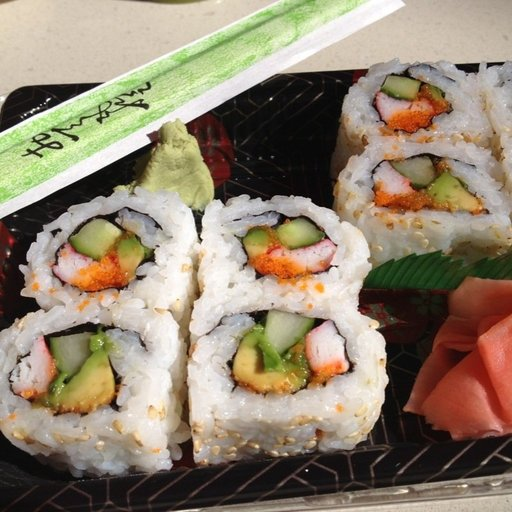

In [ ]:
# 이미지 하나 시각화함
import random
from PIL import Image

# 랜덤 시드 설정함
# random.seed(42) # 주석 해제하면 매번 같은 랜덤 이미지가 선택됨

# 1. 모든 이미지 경로 가져옴 (*는 "어떤 조합이든 가능"하다는 의미임)
image_path_list = list(image_path.glob("*/*/*.jpg")) # train/test, class 폴더 안의 모든 jpg 이미지 경로를 리스트로 변환함
print(image_path_list[:3])                           # 앞에서 3개의 이미지 경로만 확인함

# 2. 랜덤 이미지 경로 하나 선택함
random_image_path = random.choice(image_path_list)   # 전체 이미지 경로 중 하나를 무작위로 선택함
print(random_image_path)                             # 선택된 이미지 경로 출력함

# 3. 경로 이름에서 이미지 클래스 가져옴
image_class = random_image_path.parent.stem          # 이미지가 들어있는 부모 폴더 이름을 클래스 이름으로 가져옴
print(image_class)                                   # 이미지 클래스 출력함

# 4. 이미지 열기
img = Image.open(random_image_path)                  # 선택한 이미지 경로를 PIL 이미지로 열어줌

# 이미지 메타데이터 출력함
print(f"Random image path: {random_image_path}")     # 랜덤으로 선택된 이미지 경로 출력함
print(f"Image class: {image_class}")                 # 이미지 클래스 출력함
print(f"Image height: {img.height}")                 # 이미지 높이 출력함
print(f"Image width: {img.width}")                   # 이미지 너비 출력함

img                                                    # 노트북에서 이미지를 직접 출력함

# 특정 이미지 경로를 직접 열고 싶을 때 사용할 수 있음
# Image.open("/content/data/pizza_steak_sushi/test/pizza/194643.jpg")

- `random`과 `PIL.Image`를 import함.
- `image_path.glob("*/*/*.jpg")`를 사용해 데이터 폴더 안의 모든 `.jpg` 이미지 경로를 가져옴.
- `*/*/*.jpg`에서 `*`는 어떤 폴더 이름이 와도 된다는 의미임.
- `random.choice()`를 사용해 전체 이미지 경로 중 하나를 랜덤으로 선택함.
- 선택된 이미지 경로의 부모 폴더 이름을 가져와 이미지 클래스를 확인함.
- `Image.open()`을 사용해 선택된 이미지를 열어봄.
- 이미지 경로, 클래스 이름, 높이, 너비 정보를 출력함.
- 마지막 줄의 `img`를 통해 노트북에서 이미지를 직접 시각화함.

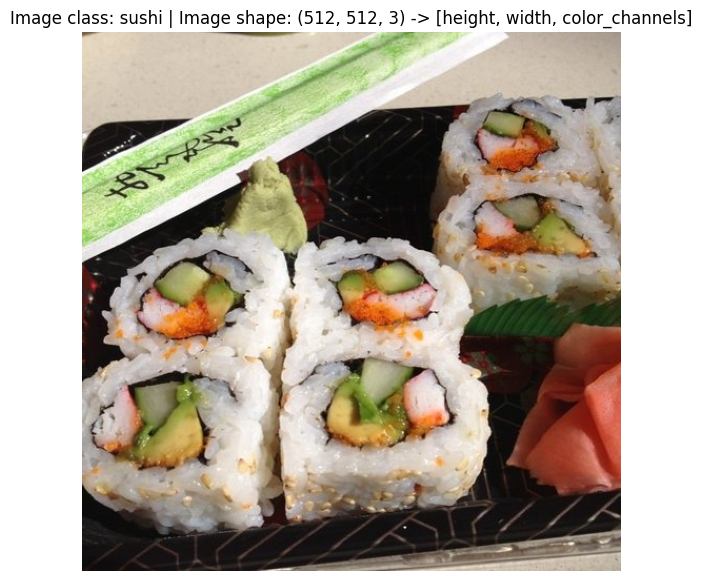

In [ ]:
# Do the image visualization with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

폴더 안에 이미지들이 준비되어 있음.

이제 이미지들을 PyTorch와 호환되도록 만들어야 함.

1. 데이터를 텐서로 변환함.
2. 텐서 데이터를 `torch.utils.data.Dataset`으로 만들고, 이후 `torch.utils.data.DataLoader`로 변환함.

In [ ]:
# 3.1 Transforming data with torchvision.transforms
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

3.1 `torchvision.transforms`로 데이터 변환하기

- `torch`, `DataLoader`, `datasets`, `transforms`를 import함.
- `transforms.Compose()`를 사용해 여러 이미지 변환 과정을 하나로 묶음.
- `transforms.Resize(size=(64, 64))`로 모든 이미지 크기를 `64x64`로 맞춤.
- `transforms.RandomHorizontalFlip(p=0.5)`로 이미지를 50% 확률로 좌우 반전함.
- `transforms.ToTensor()`로 이미지를 PyTorch 텐서로 변환함.
- `ToTensor()`는 이미지 픽셀 값을 `0~255` 범위에서 `0~1` 범위로 변환함.
- `plot_transformed_images()` 함수를 만들어 원본 이미지와 변환된 이미지를 비교해 시각화함.
- `random.sample()`을 사용해 이미지 경로 중 일부를 랜덤으로 선택함.
- `Image.open()`으로 이미지를 열고, `matplotlib`으로 원본 이미지와 변환된 이미지를 나란히 출력함.
- `permute(1, 2, 0)`을 사용해 텐서 차원 순서를 `matplotlib`에서 볼 수 있는 형태로 바꿈.
- 마지막으로 `plot_transformed_images()`를 실행해 랜덤 이미지 3장을 원본/변환본으로 비교함.

In [ ]:
# 이미지를 텐서로 바꾸기 위한 transform 작성함
data_transform = transforms.Compose([
    # 이미지를 64x64x3 크기로 조정함
    # 64 height, 64 width, 3 color channels를 의미함
    transforms.Resize(size=(64, 64)),

    # 이미지를 50% 확률로 좌우 반전함
    transforms.RandomHorizontalFlip(p=0.5),

    # 이미지를 torch.Tensor로 변환함
    # 모든 픽셀 값을 0~255 범위에서 0~1 범위로 변환함
    transforms.ToTensor()
])

In [ ]:
random.sample(image_path_list, k=3)

[PosixPath('data/pizza_steak_sushi/train/pizza/3505182.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3251688.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3281494.jpg')]

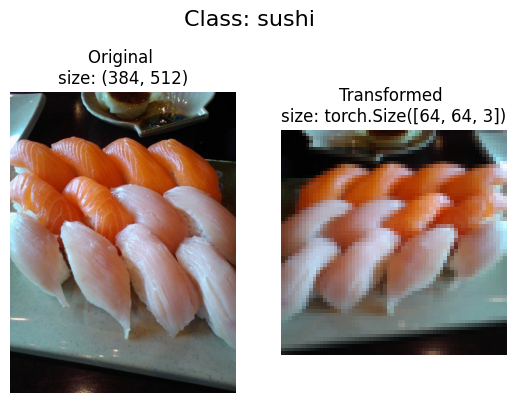

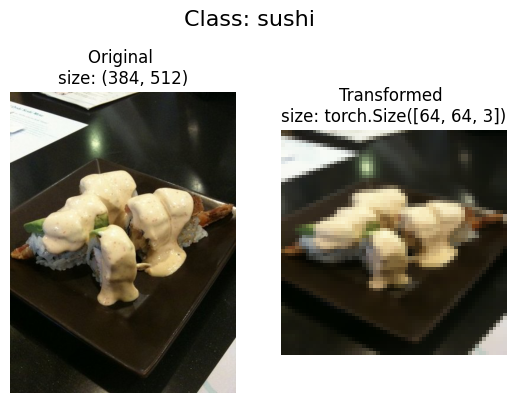

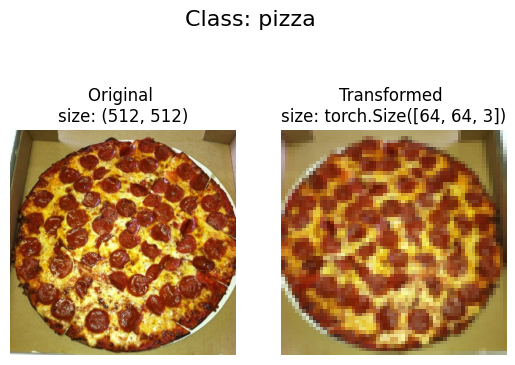

In [ ]:
# 변환된 이미지를 시각화하는 함수 작성함
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """
    image_paths에서 랜덤 이미지를 선택해 원본 이미지와 변환된 이미지를 함께 출력함.
    """
    random.seed(seed)                                  # 랜덤 결과 재현을 위해 시드 고정함
    random_image_paths = random.sample(image_paths, k=n) # 이미지 경로 중 n개를 랜덤으로 선택함

    for image_path in random_image_paths:
        with Image.open(image_path) as f:              # 이미지 파일을 열어줌
            fig, ax = plt.subplots(nrows=1, ncols=2)   # 원본/변환 이미지를 나란히 그릴 subplot 생성함

            ax[0].imshow(f)                            # 원본 이미지 출력함
            ax[0].set_title(f"Original \nsize: {f.size}") # 원본 이미지 크기 표시함
            ax[0].axis("off")                          # 축 표시 제거함

            # 이미지 변환 후 출력함
            # permute()를 사용해 matplotlib과 호환되는 차원 순서로 변경함
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)            # 변환된 이미지 출력함
            ax[1].set_title(f"Transformed \nsize: {transformed_image.shape}") # 변환된 이미지 크기 표시함
            ax[1].axis("off")                          # 축 표시 제거함

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16) # 이미지 클래스 표시함

# 랜덤 이미지 3장을 원본/변환본으로 비교함
plot_transformed_images(
    image_path_list,
    transform=data_transform,
    n=3
)

# 이미지 경로 중 3개를 랜덤으로 선택해 확인함
random.sample(image_path_list, k=3)

### Load image data using `ImageFolder`

> `ImageFolder`를 사용해 이미지 데이터 불러오기

In [ ]:
### ImageFolder를 사용해 이미지 데이터 불러오기

# ImageFolder를 사용해 Dataset 생성함
from torchvision import datasets

train_data = datasets.ImageFolder(
    root=train_dir,              # 이미지가 들어있는 훈련용 폴더 경로 지정함
    transform=data_transform,    # 이미지 데이터에 적용할 변환 지정함
    target_transform=None        # 라벨에 적용할 변환 지정함, 필요 없으므로 None으로 설정함
)

test_data = datasets.ImageFolder(
    root=test_dir,               # 이미지가 들어있는 테스트용 폴더 경로 지정함
    transform=data_transform,    # 이미지 데이터에 적용할 변환 지정함
    target_transform=None        # 라벨에 적용할 변환 지정함, 필요 없으므로 None으로 설정함
)

# 생성된 훈련/테스트 Dataset 확인함
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
# Check the lengths
len(train_data), len(test_data)

(225, 75)

In [ ]:
# train/test Dataset을 DataLoader로 변환함
from torch.utils.data import DataLoader

BATCH_SIZE = 1 # 한 번에 불러올 데이터 개수를 1개로 설정함

train_dataloader = DataLoader(
    dataset=train_data,          # 훈련용 Dataset 지정함
    batch_size=BATCH_SIZE,       # 한 번에 1개씩 데이터를 불러옴
    num_workers=os.cpu_count(),  # 사용 가능한 CPU 코어 수만큼 데이터 로딩에 활용함
    shuffle=True                 # 훈련 데이터는 매 epoch마다 순서를 섞음
)

test_dataloader = DataLoader(
    dataset=test_data,           # 테스트용 Dataset 지정함
    batch_size=BATCH_SIZE,       # 한 번에 1개씩 데이터를 불러옴
    num_workers=os.cpu_count(),  # 사용 가능한 CPU 코어 수만큼 데이터 로딩에 활용함
    shuffle=False                # 테스트 데이터는 평가용이므로 순서를 섞지 않음
)

# 생성된 train/test DataLoader 확인함
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7cb9c1696660>,
 <torch.utils.data.dataloader.DataLoader at 0x7cb9c1ab7f20>)

In [ ]:
# How many batches of images are in our data loaders?
len(train_dataloader), len(test_dataloader)

(225, 75)

In [ ]:
# train_dataloader에서 배치 하나 꺼내기
img, label = next(iter(train_dataloader)) # DataLoader를 iterator로 바꾼 뒤 첫 번째 배치를 가져옴

# 현재 batch size는 1임
# 위의 batch_size 파라미터를 바꿔보고 출력 shape이 어떻게 달라지는지 확인할 수 있음
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]") # 이미지 텐서 shape 출력함
print(f"Label shape: {label.shape}")                                             # 라벨 텐서 shape 출력함

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## 3. Recreate `model_0` we built in section 7 of notebook 04.

3. 노트북 04의 section 7에서 만든 `model_0`을 다시 만들어보세요.

- `model_0`은 TinyVGG 구조를 기반으로 만든 이미지 분류 모델임.
- `nn.Module`을 상속받아 `TinyVGG` 클래스를 정의함.
- 첫 번째 convolution

In [ ]:
import torch
from torch import nn

class TinyVGG(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        # 첫 번째 합성곱 블록 생성함
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,    # 입력 이미지의 채널 수 지정함
                out_channels=hidden_units,  # 출력 채널 수를 hidden_units로 지정함
                kernel_size=3,              # 3x3 필터를 사용함
                stride=1,                   # 필터를 한 칸씩 이동함
                padding=1                   # 입력과 출력의 가로/세로 크기를 유지하기 위해 padding 적용함
            ),
            nn.ReLU(),                      # 비선형성을 추가함

            nn.Conv2d(
                in_channels=hidden_units,   # 이전 Conv2d의 출력 채널 수를 입력 채널로 사용함
                out_channels=hidden_units,  # 출력 채널 수를 hidden_units로 유지함
                kernel_size=3,              # 3x3 필터를 사용함
                stride=1,                   # 필터를 한 칸씩 이동함
                padding=1                   # 가로/세로 크기를 유지함
            ),
            nn.ReLU(),                      # 비선형성을 추가함
            nn.MaxPool2d(kernel_size=2)     # 이미지의 가로/세로 크기를 절반으로 줄임
        )

        # 두 번째 합성곱 블록 생성함
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,   # 첫 번째 블록의 출력 채널 수를 입력으로 받음
                out_channels=hidden_units,  # 출력 채널 수를 hidden_units로 유지함
                kernel_size=3,              # 3x3 필터를 사용함
                stride=1,                   # 필터를 한 칸씩 이동함
                padding=1                   # 가로/세로 크기를 유지함
            ),
            nn.ReLU(),                      # 비선형성을 추가함

            nn.Conv2d(
                in_channels=hidden_units,   # 이전 Conv2d의 출력 채널 수를 입력으로 받음
                out_channels=hidden_units,  # 출력 채널 수를 hidden_units로 유지함
                kernel_size=3,              # 3x3 필터를 사용함
                stride=1,                   # 필터를 한 칸씩 이동함
                padding=1                   # 가로/세로 크기를 유지함
            ),
            nn.ReLU(),                      # 비선형성을 추가함
            nn.MaxPool2d(kernel_size=2)     # 이미지의 가로/세로 크기를 다시 절반으로 줄임
        )

        # 분류기 블록 생성함
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # 다차원 이미지 텐서를 1차원 벡터로 펼침
            nn.Linear(
                in_features=hidden_units * 16 * 16, # 64x64 이미지가 두 번 pooling되어 16x16이 되므로 입력 특성 수 지정함
                out_features=output_shape            # 최종 출력 클래스 수 지정함
            )
        )

    def forward(self, x):
        # 입력 데이터를 첫 번째 합성곱 블록에 통과시킴
        x = self.conv_block_1(x)
        # print(f"Layer 1 shape: {x.shape}") # 첫 번째 블록 통과 후 shape 확인용 코드임

        # 두 번째 합성곱 블록에 통과시킴
        x = self.conv_block_2(x)
        # print(f"Layer 2 shape: {x.shape}") # 두 번째 블록 통과 후 shape 확인용 코드임

        # 분류기에 통과시켜 최종 예측값을 출력함
        x = self.classifier(x)
        # print(f"Layer 3 shape: {x.shape}") # 분류기 통과 후 shape 확인용 코드임

        return x

In [ ]:
# TinyVGG 모델 인스턴스 생성함
model_0 = TinyVGG(
    input_shape=3,                 # 입력 이미지의 색상 채널 수 지정함, RGB 이미지이므로 3임
    hidden_units=10,               # 합성곱 레이어에서 사용할 은닉 채널 수를 10으로 지정함
    output_shape=len(class_names)  # 최종 출력 클래스 수를 class_names 길이로 지정함
).to(device)                       # 모델을 현재 사용 중인 device로 이동함

# 생성된 모델 구조 확인함
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

### 출력값 의미

- 출력된 `TinyVGG(...)`는 `model_0` 안에 어떤 레이어들이 들어있는지 보여줌.
- 모델은 크게 `conv_block_1`, `conv_block_2`, `classifier` 세 부분으로 구성됨.

#### `conv_block_1`

- 첫 번째 합성곱 블록임.
- 입력 이미지의 채널 수는 3개이고, 출력 채널 수는 10개임.
- 첫 번째 `Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))`는 RGB 이미지 3채널을 입력받아 10개의 특징 맵을 만들어냄.
- `kernel_size=(3, 3)`은 3x3 크기의 필터를 사용한다는 의미임.
- `stride=(1, 1)`은 필터가 가로/세로 방향으로 한 칸씩 이동한다는 의미임.
- `padding=(1, 1)`은 입력 이미지 주변에 padding을 추가해 합성곱 후에도 가로/세로 크기를 유지한다는 의미임.
- `ReLU()`는 음수 값을 0으로 바꾸고 비선형성을 추가하는 활성화 함수임.
- 두 번째 `Conv2d(10, 10, ...)`은 10개의 입력 채널을 받아 다시 10개의 특징 맵을 출력함.
- `MaxPool2d(kernel_size=2, stride=2)`는 이미지의 가로/세로 크기를 절반으로 줄임.

#### `conv_block_2`

- 두 번째 합성곱 블록임.
- 첫 번째 블록에서 나온 10개의 채널을 입력으로 받음.
- `Conv2d(10, 10, ...)` 레이어 두 개를 사용해 특징을 더 추출함.
- 각 합성곱 뒤에는 `ReLU()`가 적용됨.
- 마지막의 `MaxPool2d(kernel_size=2, stride=2)`로 이미지의 가로/세로 크기를 다시 절반으로 줄임.
- 입력 이미지 크기가 `64x64`라면 첫 번째 pooling 후 `32x32`, 두 번째 pooling 후 `16x16`이 됨.

#### `classifier`

- `classifier`는 합성곱 블록에서 추출된 특징을 사용해 최종 클래스를 예측하는 부분임.
- `Flatten(start_dim=1, end_dim=-1)`은 배치 차원을 제외한 나머지 차원을 1차원 벡터로 펼침.
- 두 번의 pooling 후 텐서 크기는 `10 x 16 x 16`이 됨.
- 따라서 `Linear` 레이어의 입력 특성 수는 `10 * 16 * 16 = 2560`이 됨.
- `Linear(in_features=2560, out_features=3)`은 2560개의 입력 특징을 받아 3개의 클래스 점수로 변환함.
- `out_features=3`은 최종 예측 클래스가 3개라는 의미임.

In [ ]:
len(class_names)

3

In [ ]:
16*16*10

2560

In [ ]:
# Pass dummy data through model
dummy_x = torch.rand(size=[1, 3, 64, 64])
model_0(dummy_x.to(device))

tensor([[ 0.0024,  0.0365, -0.0325]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

## 4. Create training and testing functions for `model_0`.

> `model_0`을 위한 훈련 함수와 테스트 함수를 만드세요.

In [ ]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer
):
    # 모델을 훈련 모드로 설정함
    model.train()

    # train loss와 train accuracy 값을 초기화함
    train_loss, train_acc = 0, 0

    # DataLoader를 반복하면서 배치 단위 데이터 가져옴
    for batch, (X, y) in enumerate(dataloader):
        # 데이터를 target device로 이동함
        X, y = X.to(device), y.to(device)

        # 1. 순전파 수행함
        y_pred = model(X)
        # print(y_pred) # 모델 예측값 확인용 코드임

        # 2. loss 계산 및 누적함
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. optimizer gradient 초기화함
        optimizer.zero_grad()

        # 4. loss 기준으로 역전파 수행함
        loss.backward()

        # 5. optimizer step으로 모델 파라미터 업데이트함
        optimizer.step()

        # 모든 배치에 대해 accuracy 계산 및 누적함
        y_pred_class = torch.argmax(
            torch.softmax(y_pred, dim=1),
            dim=1
        ) # logits를 확률로 바꾼 뒤 가장 높은 확률의 클래스를 선택함

        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # 배치별 평균 loss와 평균 accuracy 계산함
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc

In [ ]:
def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module
):
    # 모델을 평가 모드로 설정함
    model.eval()

    # test loss와 test accuracy 값을 초기화함
    test_loss, test_acc = 0, 0

    # inference mode를 켜서 gradient 계산을 비활성화함
    with torch.inference_mode():
        # DataLoader를 반복하면서 배치 단위 데이터 가져옴
        for batch, (X, y) in enumerate(dataloader):
            # 데이터를 target device로 이동함
            X, y = X.to(device), y.to(device)

            # 1. 순전파 수행함
            test_pred_logits = model(X)
            # print(test_pred_logits) # 모델 예측값 확인용 코드임

            # 2. loss 계산 및 누적함
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # accuracy 계산 및 누적함
            test_pred_labels = test_pred_logits.argmax(dim=1) # 가장 큰 logit 값을 가진 클래스를 예측 라벨로 선택함
            test_acc += (
                (test_pred_labels == y).sum().item() / len(test_pred_labels)
            )

    # 배치별 평균 loss와 평균 accuracy 계산함
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc

In [ ]:
from tqdm.auto import tqdm

def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
    epochs: int = 5
):
    # 결과를 저장할 딕셔너리 생성함
    results = {
        "train_loss": [], # 각 epoch의 train loss를 저장함
        "train_acc": [],  # 각 epoch의 train accuracy를 저장함
        "test_loss": [],  # 각 epoch의 test loss를 저장함
        "test_acc": []    # 각 epoch의 test accuracy를 저장함
    }

    # 지정한 epoch 수만큼 train_step과 test_step을 반복함
    for epoch in tqdm(range(epochs)):
        # 훈련 단계 실행함
        train_loss, train_acc = train_step(
            model=model,                    # 학습할 모델 지정함
            dataloader=train_dataloader,    # 훈련용 DataLoader 지정함
            loss_fn=loss_fn,                # loss 함수 지정함
            optimizer=optimizer             # optimizer 지정함
        )

        # 테스트 단계 실행함
        test_loss, test_acc = test_step(
            model=model,                    # 평가할 모델 지정함
            dataloader=test_dataloader,     # 테스트용 DataLoader 지정함
            loss_fn=loss_fn                 # loss 함수 지정함
        )

        # 현재 epoch에서 일어난 결과를 출력함
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 결과 딕셔너리에 각 지표 값을 추가함
        results["train_loss"].append(train_loss) # train loss 저장함
        results["train_acc"].append(train_acc)   # train accuracy 저장함
        results["test_loss"].append(test_loss)   # test loss 저장함
        results["test_acc"].append(test_acc)     # test accuracy 저장함

    # 모든 epoch의 결과가 담긴 딕셔너리 반환함
    return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer.

> 5. exercise 3에서 만든 모델을 5, 20, 50 epochs 동안 학습해보세요. 결과에 어떤 일이 일어나나요?

In [ ]:
# 5 epochs 동안 학습함
torch.manual_seed(42)       # CPU 연산의 랜덤 시드를 고정함
torch.cuda.manual_seed(42)  # GPU 연산의 랜덤 시드를 고정함

model_0 = TinyVGG(
    input_shape=3,                # 입력 이미지의 색상 채널 수 지정함, RGB 이미지이므로 3임
    hidden_units=10,              # 합성곱 레이어의 hidden channel 수를 10으로 설정함
    output_shape=len(class_names) # 최종 출력 클래스 수를 class_names 길이로 설정함
).to(device)                      # 모델을 target device로 이동함

loss_fn = nn.CrossEntropyLoss()   # 다중 클래스 분류용 loss function 설정함

optimizer = torch.optim.Adam(
    model_0.parameters(),         # model_0의 학습 가능한 파라미터를 optimizer에 전달함
    lr=0.001                      # learning rate를 0.001로 설정함
)

model_0_results = train(
    model=model_0,                         # 학습할 모델 지정함
    train_dataloader=train_dataloader,     # 훈련용 DataLoader 지정함
    test_dataloader=test_dataloader,       # 테스트용 DataLoader 지정함
    optimizer=optimizer,                   # Adam optimizer 지정함
    epochs=5                               # 5 epochs 동안 학습함
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1182 | train_acc: 0.2889 | test_loss: 1.0962 | test_acc: 0.3200
Epoch: 2 | train_loss: 1.1025 | train_acc: 0.3467 | test_loss: 1.1054 | test_acc: 0.2533
Epoch: 3 | train_loss: 1.0999 | train_acc: 0.3244 | test_loss: 1.0998 | test_acc: 0.3333
Epoch: 4 | train_loss: 1.0990 | train_acc: 0.3244 | test_loss: 1.0999 | test_acc: 0.3333
Epoch: 5 | train_loss: 1.0990 | train_acc: 0.3378 | test_loss: 1.1004 | test_acc: 0.3333


In [ ]:
# 20 epochs 동안 학습함
torch.manual_seed(42)       # CPU 연산의 랜덤 시드를 고정함
torch.cuda.manual_seed(42)  # GPU 연산의 랜덤 시드를 고정함

model_1 = TinyVGG(
    input_shape=3,                # 입력 이미지의 색상 채널 수 지정함, RGB 이미지이므로 3임
    hidden_units=10,              # 합성곱 레이어의 hidden channel 수를 10으로 설정함
    output_shape=len(class_names) # 최종 출력 클래스 수를 class_names 길이로 설정함
).to(device)                      # 모델을 target device로 이동함

loss_fn = nn.CrossEntropyLoss()   # 다중 클래스 분류용 loss function 설정함

optimizer = torch.optim.Adam(
    model_1.parameters(),         # model_1의 학습 가능한 파라미터를 optimizer에 전달함
    lr=0.001                      # learning rate를 0.001로 설정함
)

model_1_results = train(
    model=model_1,                         # 학습할 모델 지정함
    train_dataloader=train_dataloader,     # 훈련용 DataLoader 지정함
    test_dataloader=test_dataloader,       # 테스트용 DataLoader 지정함
    optimizer=optimizer,                   # Adam optimizer 지정함
    epochs=20                              # 20 epochs 동안 학습함
)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1179 | train_acc: 0.2800 | test_loss: 1.0960 | test_acc: 0.3733
Epoch: 2 | train_loss: 1.1010 | train_acc: 0.3244 | test_loss: 1.0996 | test_acc: 0.2533
Epoch: 3 | train_loss: 1.0993 | train_acc: 0.2978 | test_loss: 1.0998 | test_acc: 0.3333
Epoch: 4 | train_loss: 1.0990 | train_acc: 0.3333 | test_loss: 1.1001 | test_acc: 0.3333
Epoch: 5 | train_loss: 1.0992 | train_acc: 0.3378 | test_loss: 1.1004 | test_acc: 0.3333
Epoch: 6 | train_loss: 1.0977 | train_acc: 0.3422 | test_loss: 1.1007 | test_acc: 0.2533
Epoch: 7 | train_loss: 1.0989 | train_acc: 0.3022 | test_loss: 1.1004 | test_acc: 0.3333
Epoch: 8 | train_loss: 1.0990 | train_acc: 0.3200 | test_loss: 1.1013 | test_acc: 0.3333
Epoch: 9 | train_loss: 1.0985 | train_acc: 0.3333 | test_loss: 1.0994 | test_acc: 0.3200
Epoch: 10 | train_loss: 1.0942 | train_acc: 0.3822 | test_loss: 1.1021 | test_acc: 0.3333
Epoch: 11 | train_loss: 1.0989 | train_acc: 0.3467 | test_loss: 1.1024 | test_acc: 0.3333
Epoch: 12 | train_l

In [ ]:
# 50 epochs 동안 학습함
torch.manual_seed(42)       # CPU 연산의 랜덤 시드를 고정함
torch.cuda.manual_seed(42)  # GPU 연산의 랜덤 시드를 고정함

model_2 = TinyVGG(
    input_shape=3,                # 입력 이미지의 색상 채널 수 지정함, RGB 이미지이므로 3임
    hidden_units=10,              # 합성곱 레이어의 hidden channel 수를 10으로 설정함
    output_shape=len(class_names) # 최종 출력 클래스 수를 class_names 길이로 설정함
).to(device)                      # 모델을 target device로 이동함

loss_fn = nn.CrossEntropyLoss()   # 다중 클래스 분류용 loss function 설정함

optimizer = torch.optim.Adam(
    model_2.parameters(),         # model_2의 학습 가능한 파라미터를 optimizer에 전달함
    lr=0.001                      # learning rate를 0.001로 설정함
)

model_2_results = train(
    model=model_2,                         # 학습할 모델 지정함
    train_dataloader=train_dataloader,     # 훈련용 DataLoader 지정함
    test_dataloader=test_dataloader,       # 테스트용 DataLoader 지정함
    optimizer=optimizer,                   # Adam optimizer 지정함
    epochs=50                              # 50 epochs 동안 학습함
)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1182 | train_acc: 0.2889 | test_loss: 1.0962 | test_acc: 0.3200
Epoch: 2 | train_loss: 1.1025 | train_acc: 0.3511 | test_loss: 1.1057 | test_acc: 0.2533
Epoch: 3 | train_loss: 1.1015 | train_acc: 0.3422 | test_loss: 1.0993 | test_acc: 0.3333
Epoch: 4 | train_loss: 1.0990 | train_acc: 0.3467 | test_loss: 1.0997 | test_acc: 0.3333
Epoch: 5 | train_loss: 1.0990 | train_acc: 0.3378 | test_loss: 1.1007 | test_acc: 0.3333
Epoch: 6 | train_loss: 1.0995 | train_acc: 0.3467 | test_loss: 1.0970 | test_acc: 0.3467
Epoch: 7 | train_loss: 1.0995 | train_acc: 0.3333 | test_loss: 1.1057 | test_acc: 0.3733
Epoch: 8 | train_loss: 1.0799 | train_acc: 0.4978 | test_loss: 1.0795 | test_acc: 0.3600
Epoch: 9 | train_loss: 0.9848 | train_acc: 0.5289 | test_loss: 1.0228 | test_acc: 0.4933
Epoch: 10 | train_loss: 0.9206 | train_acc: 0.5911 | test_loss: 0.9977 | test_acc: 0.4400
Epoch: 11 | train_loss: 0.8609 | train_acc: 0.6356 | test_loss: 1.0029 | test_acc: 0.4533
Epoch: 12 | train_l

모델이 마지막쯤에 과적합되기 시작한 것처럼 보임  
(훈련 데이터에서는 테스트 데이터보다 훨씬 더 좋은 성능을 보임).

이를 해결하려면, 과적합을 방지하는 방법들을 도입해야 함.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

6. 모델의 hidden units 수를 두 배로 늘리고 20 epochs 동안 학습해보세요. 결과는 어떻게 되나요?

- 모델의 hidden units 수를 기존보다 2배로 늘림.
- 늘어난 모델을 20 epochs 동안 학습함.
- 학습 결과가 기존 모델과 어떻게 달라지는지 확인함.

In [ ]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_3 = TinyVGG(input_shape=3,
                  hidden_units=20, # use 20 hidden units instead of 10
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_3.parameters(), lr=0.001)

model_3_results = train(model=model_3,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        epochs=20) # train for 20 epochs

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0987 | train_acc: 0.3644 | test_loss: 1.0791 | test_acc: 0.3467
Epoch: 2 | train_loss: 1.0460 | train_acc: 0.4533 | test_loss: 1.0234 | test_acc: 0.4533
Epoch: 3 | train_loss: 0.9730 | train_acc: 0.5511 | test_loss: 0.9958 | test_acc: 0.4800
Epoch: 4 | train_loss: 0.8973 | train_acc: 0.5911 | test_loss: 0.9852 | test_acc: 0.5200
Epoch: 5 | train_loss: 0.9051 | train_acc: 0.6000 | test_loss: 0.9783 | test_acc: 0.4400
Epoch: 6 | train_loss: 0.8457 | train_acc: 0.6222 | test_loss: 0.9852 | test_acc: 0.4667
Epoch: 7 | train_loss: 0.8403 | train_acc: 0.6578 | test_loss: 1.0852 | test_acc: 0.4800
Epoch: 8 | train_loss: 0.7914 | train_acc: 0.6533 | test_loss: 0.9827 | test_acc: 0.4533
Epoch: 9 | train_loss: 0.7634 | train_acc: 0.6533 | test_loss: 1.0407 | test_acc: 0.4000
Epoch: 10 | train_loss: 0.7841 | train_acc: 0.6444 | test_loss: 1.0056 | test_acc: 0.4933
Epoch: 11 | train_loss: 0.7302 | train_acc: 0.6889 | test_loss: 0.9339 | test_acc: 0.5200
Epoch: 12 | train_l

<결과값 해석>
- 초반에는 train loss와 test loss가 모두 감소하면서 모델이 어느 정도 학습되는 모습을 보임.
- `train_loss`는 1 epoch의 `1.0987`에서 20 epoch의 `0.4753`까지 꾸준히 감소함.
- `train_acc`는 1 epoch의 `0.3644`에서 20 epoch의 `0.8000`까지 상승함.
- 즉, 훈련 데이터에 대해서는 모델 성능이 계속 좋아지고 있음.
- 하지만 `test_loss`는 안정적으로 감소하지 않고 중간부터 크게 흔들림.
- 특히 18 epoch에서 `test_loss=1.8131`, 19 epoch에서 `test_loss=2.0284`로 크게 증가함.
- `test_acc`도 0.4~0.52 사이에서 크게 좋아지지 못하고 정체됨.
- 마지막 20 epoch에서 `train_acc=0.8000`인데 `test_acc=0.5067`임.
- 훈련 정확도와 테스트 정확도 차이가 꽤 크므로 모델이 훈련 데이터에 과적합되고 있다고 볼 수 있음.

<결론>

- hidden units 수를 두 배로 늘렸더니 훈련 데이터 성능은 좋아졌지만, 테스트 데이터 성능은 크게 좋아지지 않았음.
- 즉, 모델의 표현력은 증가했지만 일반화 성능은 개선되지 않았음.
- 결과적으로 hidden units 수를 늘려도 여전히 overfitting이 발생함.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

> Q. step 6에서 사용한 모델에 사용하는 데이터를 두 배로 늘리고 20 epochs 동안 학습해보세요. 결과에 어떤 일이 일어나나요?

- step 6에서 사용한 모델을 그대로 사용함.
- 모델의 hidden units 수는 두 배로 늘린 상태를 유지함.
- 사용하는 데이터셋의 양을 두 배로 늘림.
- 기존에는 Food101 데이터셋의 10% subset을 사용했다면, 이번에는 20% subset을 사용함.
- 데이터를 두 배로 늘린 뒤 모델을 20 epochs 동안 학습함.
- 학습 결과가 step 6과 비교해 어떻게 달라지는지 확인함.

> 참고

- Food101 데이터셋을 더 크게 만들고 싶다면 custom data creation notebook을 사용할 수 있음.
- 이미 GitHub에 준비된 두 배 크기의 데이터셋도 사용할 수 있음.
- 이 데이터셋은 기존 10% subset 대신 20% subset으로 구성된 `pizza_steak_sushi_20_percent.zip` 파일임.
- 이 데이터를 노트북으로 가져오려면 exercise 2에서 했던 것처럼 다운로드 코드를 직접 작성해야 함.

In [ ]:
# GitHub에서 Pizza/Steak/Sushi 20% 데이터 다운로드함
import requests
import zipfile
from pathlib import Path

# 데이터 폴더 경로 설정함
data_path = Path("data/")                                  # 데이터를 저장할 기본 폴더 경로 지정함
image_path = data_path / "pizza_steak_sushi_20_percent"    # 20% 이미지 데이터가 저장될 폴더 경로 지정함

# 이미지 폴더가 존재하지 않으면 다운로드하고 준비함
if image_path.is_dir():
    print(f"{image_path} directory exists.")               # 이미지 폴더가 이미 존재하면 안내 문구 출력함
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)          # 상위 폴더까지 포함해서 이미지 폴더 생성함

# pizza, steak, sushi 20% 데이터 다운로드함
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get(
        "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip"
    )                                                       # GitHub에서 20% 데이터 zip 파일 요청함
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)                               # 요청받은 zip 파일 내용을 로컬 파일에 저장함

# pizza, steak, sushi 20% 데이터 압축 해제함
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...")
    zip_ref.extractall(image_path)                         # zip 파일을 20% 이미지 폴더 경로에 압축 해제함

Did not find data/pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


In [ ]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/train'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi_20_percent/train/sushi'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi_20_percent/train/pizza'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi_20_percent/train/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/test'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/sushi'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/pizza'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi_20_percent/test/steak'.


Excellent, we now have double the training and testing images...

In [ ]:
# Turn the data into datasets and dataloaders
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

# 간단한 이미지 변환 파이프라인 생성함
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)), # 이미지를 64x64 크기로 변환함
    transforms.ToTensor()        # 이미지를 PyTorch 텐서로 변환하고 픽셀 값을 0~1 사이로 바꿈
])

# 20% 훈련 데이터셋 생성함
train_data_20_percent = ImageFolder(
    train_data_20_percent_path,  # 20% 훈련 이미지 폴더 경로 지정함
    transform=simple_transform   # 이미지 변환 적용함
)

# 20% 테스트 데이터셋 생성함
test_data_20_percent = ImageFolder(
    test_data_20_percent_path,   # 20% 테스트 이미지 폴더 경로 지정함
    transform=simple_transform   # 이미지 변환 적용함
)

# 20% 훈련 DataLoader 생성함
train_dataloader_20_percent = DataLoader(
    train_data_20_percent,       # 20% 훈련 Dataset 지정함
    batch_size=32,               # 한 번에 32개씩 데이터를 불러옴
    num_workers=os.cpu_count(),  # 사용 가능한 CPU 코어 수만큼 데이터 로딩에 활용함
    shuffle=True                 # 훈련 데이터는 매 epoch마다 순서를 섞음
)

# 20% 테스트 DataLoader 생성함
test_dataloader_20_percent = DataLoader(
    test_data_20_percent,        # 20% 테스트 Dataset 지정함
    batch_size=32,               # 한 번에 32개씩 데이터를 불러옴
    num_workers=os.cpu_count(),  # 사용 가능한 CPU 코어 수만큼 데이터 로딩에 활용함
    shuffle=False                # 테스트 데이터는 평가용이므로 순서를 섞지 않음
)

In [ ]:
# 데이터 양을 늘린 모델 학습함
torch.manual_seed(42)       # CPU 연산의 랜덤 시드를 고정함
torch.cuda.manual_seed(42)  # GPU 연산의 랜덤 시드를 고정함

model_4 = TinyVGG(
    input_shape=3,                # 입력 이미지의 색상 채널 수 지정함, RGB 이미지이므로 3임
    hidden_units=20,              # hidden units를 20으로 설정함, 기존 10보다 두 배 늘림
    output_shape=len(class_names) # 최종 출력 클래스 수를 class_names 길이로 설정함
).to(device)                      # 모델을 target device로 이동함

loss_fn = nn.CrossEntropyLoss()   # 다중 클래스 분류용 loss function 설정함

optimizer = torch.optim.Adam(
    model_4.parameters(),         # model_4의 학습 가능한 파라미터를 optimizer에 전달함
    lr=0.001                      # learning rate를 0.001로 설정함
)

model_4_results = train(
    model=model_4,                                   # 학습할 모델 지정함
    train_dataloader=train_dataloader_20_percent,    # 두 배로 늘어난 훈련 데이터 사용함
    test_dataloader=test_dataloader_20_percent,      # 두 배로 늘어난 테스트 데이터 사용함
    optimizer=optimizer,                             # Adam optimizer 지정함
    epochs=20                                        # 20 epochs 동안 학습함
)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1042 | train_acc: 0.3312 | test_loss: 1.1004 | test_acc: 0.2875
Epoch: 2 | train_loss: 1.0831 | train_acc: 0.3917 | test_loss: 1.0679 | test_acc: 0.4290
Epoch: 3 | train_loss: 1.0260 | train_acc: 0.4542 | test_loss: 0.9459 | test_acc: 0.5784
Epoch: 4 | train_loss: 0.9195 | train_acc: 0.5542 | test_loss: 0.9130 | test_acc: 0.5938
Epoch: 5 | train_loss: 0.8626 | train_acc: 0.6729 | test_loss: 0.9138 | test_acc: 0.5335
Epoch: 6 | train_loss: 0.8386 | train_acc: 0.6417 | test_loss: 1.0072 | test_acc: 0.4966
Epoch: 7 | train_loss: 0.8960 | train_acc: 0.5792 | test_loss: 0.8915 | test_acc: 0.4994
Epoch: 8 | train_loss: 0.7575 | train_acc: 0.6646 | test_loss: 0.9253 | test_acc: 0.5852
Epoch: 9 | train_loss: 0.7968 | train_acc: 0.6417 | test_loss: 0.8995 | test_acc: 0.5443
Epoch: 10 | train_loss: 0.7652 | train_acc: 0.6646 | test_loss: 0.8919 | test_acc: 0.6227
Epoch: 11 | train_loss: 0.7231 | train_acc: 0.6813 | test_loss: 0.8643 | test_acc: 0.6597
Epoch: 12 | train_l

데이터를 두 배로 늘렸음에도 모델은 여전히 과적합되고 있음  
(train loss가 test loss보다 훨씬 낮기 때문임).

더 나은 모델을 만들기 위해서는 과적합을 줄이는 다른 방법들을 추가로 살펴봐야 할 것 같음.

## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction.
* Does the model you trained in exercise 7 get it right?
* If not, what do you think you could do to improve it?

> 8. exercise 7에서 학습한 모델을 사용해 pizza/steak/sushi 중 하나인 나만의 custom image에 대해 예측을 수행하고, 예측 결과를 공유해보세요.

> - exercise 7에서 학습한 모델이 정답을 맞혔나요?
> - 맞히지 못했다면, 모델을 개선하기 위해 무엇을 할 수 있을까요?

In [ ]:
# custom image 가져오기
custom_image = "pizza_dad.jpeg" # 저장할 custom image 파일 이름 지정함

with open("pizza_dad.jpeg", "wb") as f: # 이미지를 바이너리 쓰기 모드로 열어줌
    request = requests.get(
        "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg"
    )                                  # GitHub에서 custom pizza 이미지 다운로드 요청함
    f.write(request.content)           # 다운로드한 이미지 내용을 pizza_dad.jpeg 파일로 저장함

In [ ]:
# Load the image
import torchvision
img = torchvision.io.read_image(custom_image)
img

tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

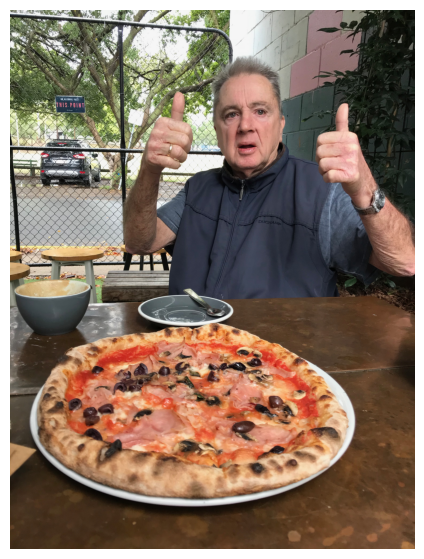

In [ ]:
# View the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0)) # matplotlib likes images in HWC (height, width, color_channels) format not CHW (color_channels, height, width)
plt.axis(False);

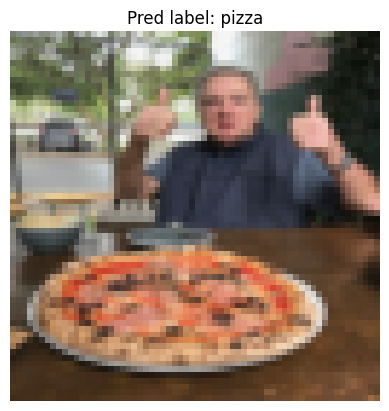

In [ ]:
# 이미지에 대해 예측 수행함
model_4.eval() # 모델을 평가 모드로 설정함

with torch.inference_mode(): # 추론 시 gradient 계산을 끔
    # 이미지 픽셀 값을 float 형태 + 0~1 범위로 변환함
    img = img / 255.

    # 이미지를 64x64 크기로 변환함
    resize = transforms.Resize((64, 64))
    img = resize(img)

    # 이미지에 batch 차원을 추가하고 target device로 이동함
    batch = img.unsqueeze(0).to(device)

    # 이미지에 대해 예측 수행함
    y_pred_logit = model_4(batch)

    # 예측 logit을 예측 라벨로 변환함
    # pred_label = torch.argmax(torch.softmax(y_pred_logit, dim=1), dim=1)
    pred_label = torch.argmax(y_pred_logit, dim=1) # softmax 없이도 가장 큰 logit의 index는 동일하게 나옴

# 이미지와 예측 결과 시각화함
plt.imshow(img.permute(1, 2, 0)) # matplotlib에서 볼 수 있도록 [C, H, W]를 [H, W, C]로 바꿈
plt.title(f"Pred label: {class_names[pred_label]}") # 예측 라벨을 제목으로 표시함
plt.axis(False); # 축 표시 제거함